# Autonomous Farming: Corn Row Alignment Scoring
We built a machine learning system that looks at top-down photos of a corn field, finds every individual corn plant, measures *where* each plant is and *which way it's leaning (growing)*, and then scores how well each plant is aligned with the row it was planted in. The output is two numbers per plant (a positional error in pixels and an angular error in degrees) rolled up into a 0–100 alignment score, with per-row averages.

## The five deliverables, mapped to sections of this notebook
| # | Deliverable | Where in notebook |
|---|-------------|-------------------|
| 1 | Detect individual corn plants in an image | §4 Training, §5 Evaluation |
| 2 | Estimate position and orientation of each plant | §6 Inference |
| 3 | Define the optimal growth line per row | §8 Optimal line |
| 4 | Compute the deviation from that line | §9 Scoring |
| 5 | Produce row-level and plant-level alignment scores | §9 Scoring, §11 Batch export |

## How it works, at a system level
1. **Camera → pixels.** A top-down image of the field.
2. **Detection model → list of plants.** A neural network (YOLO11-pose) looks at the image and returns, for each plant it finds, a bounding box plus three landmark points: the stem center, the tip of the left leaf, and the tip of the right leaf.
3. **Post-processing → measurements.** We take those three points and compute (a) the plant's position = stem location, and (b) the plant's orientation = direction of the line through the two leaf tips.
4. **Row fitting → reference lines.** We group plants by row and either use a known reference line (if we know exactly where the seeds were planted) or we fit a best-fit line through the detected stems.
5. **Scoring → numbers.** For each plant: how far is it from its row's reference line? How rotated is its leaf axis from the expected orientation? We combine these into a single 0–100 score.

---
# 1. Setup

Before doing anything interesting, we need to:

1. Confirm the GPU is working. Training on a CPU would take days.
2. Set the project folder so all outputs land in one place.
3. Import the libraries we'll use throughout.

## Before running this notebook, install these packages (once, from your terminal):

```
pip install ultralytics scikit-learn matplotlib opencv-python
```

If you see a CUDA / GPU-related error later, you may also need the GPU build of PyTorch:

```
pip uninstall torch torchvision -y
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121

In [2]:
import torch  # PyTorch — the deep learning framework YOLO is built on

# torch.cuda.is_available() returns True if an NVIDIA GPU + compatible drivers are installed.
# The `assert` line crashes loudly if this returns False, so you find out NOW, not 3 hours into training.
assert torch.cuda.is_available(), "No GPU detected. Check CUDA install / PyTorch version."

# Print GPU model name (useful to confirm you're using the right one if you have multiple).
print(f"GPU:  {torch.cuda.get_device_name(0)}")
print(f"CUDA: {torch.version.cuda}")

GPU:  NVIDIA RTX 1000 Ada Generation Laptop GPU
CUDA: 12.8


In [3]:
import os
from pathlib import Path
PROJECT_ROOT = Path(r"C:\Users\atpou\projects\T1_Corn_Alignment")

# Create the folder if it doesn't already exist. exist_ok=True means "don't error if it's already there".
PROJECT_ROOT.mkdir(parents=True, exist_ok=True)

# Change the working directory so relative paths in later cells resolve here.
os.chdir(PROJECT_ROOT)

print(f"Working from: {PROJECT_ROOT}")

Working from: C:\Users\atpou\projects\T1_Corn_Alignment


In [4]:
import json          # read/write JSON files
import shutil        # copy / delete directories
import random        # Python's built-in random number generator
import yaml          # read/write YAML files (used for YOLO's config format)
from collections import defaultdict  # a dict that auto-creates missing keys as empty lists — handy for grouping
import numpy as np              # arrays and linear algebra — the workhorse of anything numerical in Python
import cv2                      # OpenCV — image loading, drawing, classical computer vision
import matplotlib.pyplot as plt # plotting — how we visualize images inline
from sklearn.cluster import DBSCAN  # clustering algorithm we'll use for row assignment

SEED = 42
random.seed(SEED)         # seed Python's random
np.random.seed(SEED)      # seed NumPy's random
torch.manual_seed(SEED)   # seed PyTorch's random (for weight init, augmentations, etc.)

# Constants describing our annotation scheme: 3 keypoints per plant, in a fixed order.
NUM_KEYPOINTS = 3
KP_STEM  = 0   # index 0 in the keypoint list = stem center
KP_LEFT  = 1   # index 1 = leaf-tip-left
KP_RIGHT = 2   # index 2 = leaf-tip-right

---
# 2. Dataset preparation
The dataset consists of a folder of corn photos, each paired with a text file that has one line per plant: where the bounding box is, and where the three keypoints are. Both images and labels get split into `train/` and `valid/`

## Annotation format
The dataset is exported from Roboflow in "YOLOv8 Pose" format. Each label file looks like:

```
0  0.437 0.389 0.300 0.183  0.479 0.383 2   0.558 0.303 2   0.303 0.316 2
|  |____bbox (x,y,w,h)____| |_kp0 stem_|   |_kp1 left_|   |_kp2 right|
|                                          visibility flag (2 = visible, 0 = not annotated)
class ID (0 = corn)
```

All coordinates are **normalized** to [0, 1], making the labels resolution-independent.

## Expected folder structure

Unzip the Roboflow export into `PROJECT_ROOT/raw_dataset/` so it looks like this:

```
raw_dataset/
|-- train/images/*.jpg   <- training images
|-- train/labels/*.txt   <- one label file per image, same base name
|-- valid/images/*.jpg   <- validation images (model never trains on these)
|-- valid/labels/*.txt
|-- data.yaml            <- we ignore this and generate our own in section 3
```

Now, before proceeding, we need to:
1. Point to the raw dataset and count what we have
2. Eyeball a few samples (sanity check)

In [5]:
# Where the raw Roboflow export lives
RAW_DATASET = PROJECT_ROOT / 'raw_dataset'
assert RAW_DATASET.exists(), f"Unzip your Roboflow export into {RAW_DATASET}"

# Walk the expected subfolders and print counts
for split in ['train', 'valid', 'test']:   # 'test' is optional — many exports skip it
    img_dir = RAW_DATASET / split / 'images'
    lbl_dir = RAW_DATASET / split / 'labels'
    if img_dir.exists():
        # .glob('*') returns every file; len(list(...)) counts them
        n_img = len(list(img_dir.glob('*')))
        n_lbl = len(list(lbl_dir.glob('*.txt'))) if lbl_dir.exists() else 0
        print(f"{split:6s}  images={n_img:4d}  labels={n_lbl:4d}")
        # If images and labels don't match, something is wrong with the export
        if n_img != n_lbl:
            print(f"  WARNING: image count and label count don't match for {split}!")

train   images= 286  labels= 286
valid   images=  57  labels=  57
test    images=  49  labels=  49


In [6]:
def canonicalize_label_file(src_path: Path, dst_path: Path):
    """Pass-through: trust the annotator's order."""
    dst_path.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src_path, dst_path)

# We write the cleaned dataset into a separate folder so the raw export is untouched.
# This means you can re-run this cell safely without losing the original labels.
DATASET_ROOT = PROJECT_ROOT / 'dataset'

# If the cleaned dataset already exists from a previous run, delete it first.
if DATASET_ROOT.exists():
    shutil.rmtree(DATASET_ROOT)

# Walk each split (train/valid/test) and process every label file
for split in ['train', 'valid', 'test']:
    src_img = RAW_DATASET / split / 'images'
    src_lbl = RAW_DATASET / split / 'labels'
    if not src_img.exists():  # skip splits that don't exist (e.g. if no test set)
        continue

    dst_img = DATASET_ROOT / split / 'images'
    dst_lbl = DATASET_ROOT / split / 'labels'
    dst_img.mkdir(parents=True, exist_ok=True)
    dst_lbl.mkdir(parents=True, exist_ok=True)

    # Copy images (not symlinks, because Windows symlinks require admin permissions)
    for img in src_img.iterdir():
        tgt = dst_img / img.name
        if not tgt.exists():
            shutil.copy2(img, tgt)  # copy2 preserves metadata like modification time

    # Process and rewrite every label file
    for lbl in src_lbl.glob('*.txt'):
        canonicalize_label_file(lbl, dst_lbl / lbl.name)

    print(f"{split:6s}  done")

train   done
valid   done
test    done


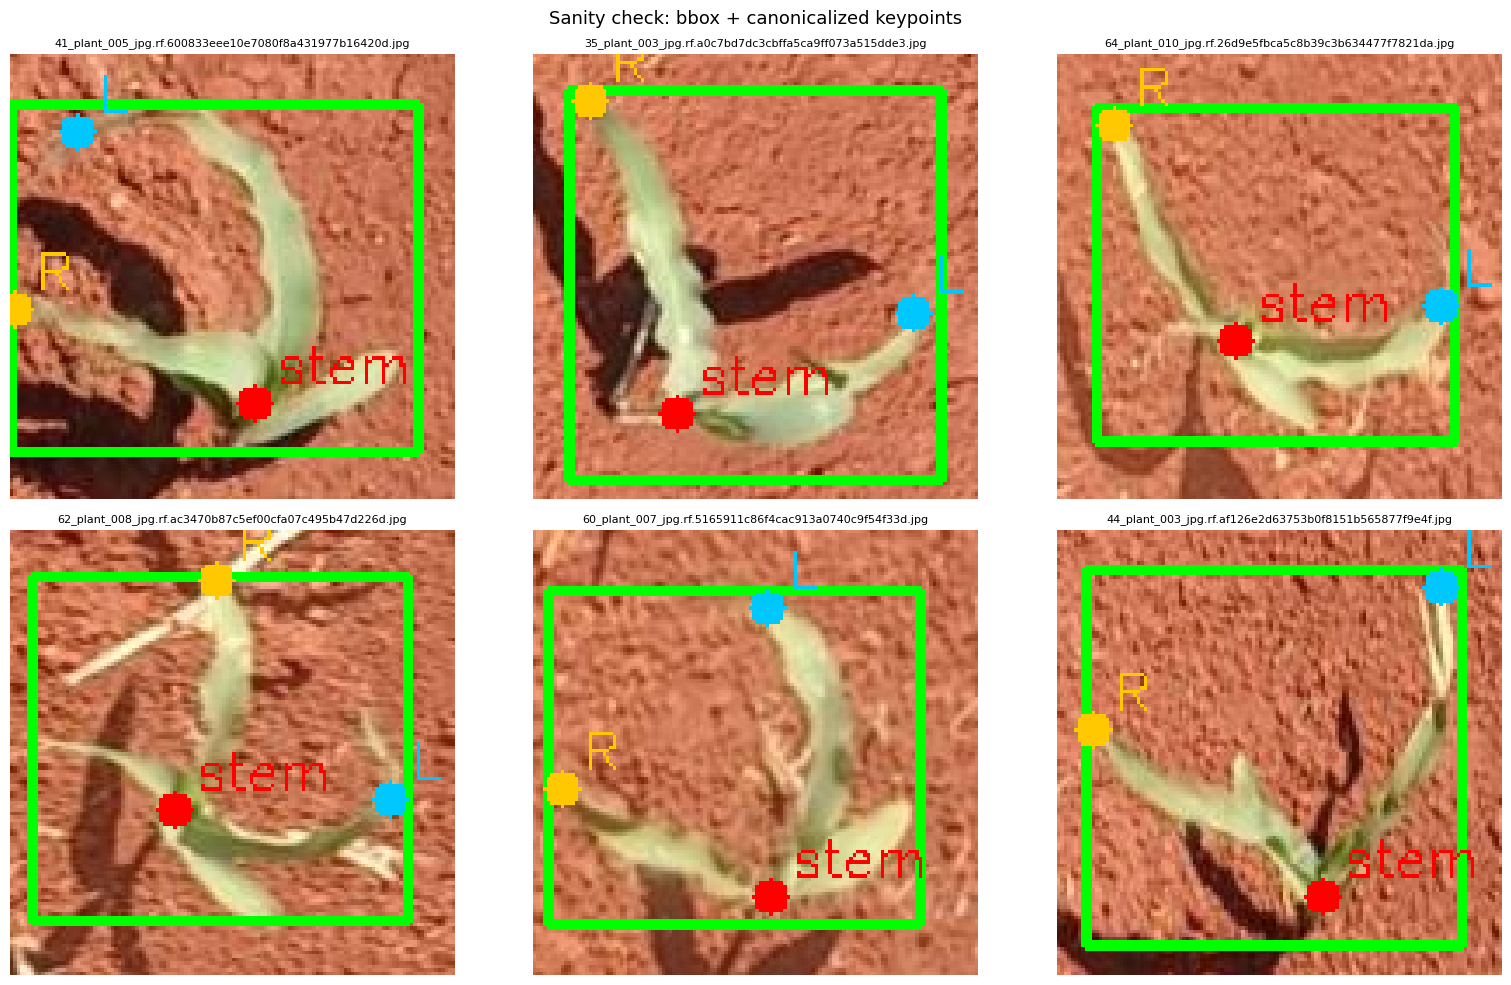

In [7]:
def draw_annotation(img, label_path):
    """
    Takes an image and its label file, and returns a copy of the image
    with the bounding box and keypoints drawn on top.
    Used for visual debugging only.
    """
    H, W = img.shape[:2]  # image height, width in pixels
    out = img.copy()      # don't modify the original

    # BGR colors (OpenCV convention) for each keypoint
    COLORS = {
        KP_STEM:  (255, 0, 0),    # red
        KP_LEFT:  (0, 200, 255),  # cyan-ish
        KP_RIGHT: (255, 200, 0),  # orange-ish
    }
    NAMES = {KP_STEM: 'stem', KP_LEFT: 'L', KP_RIGHT: 'R'}

    if not label_path.exists():
        return out  # no labels — just return the raw image

    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5 + NUM_KEYPOINTS * 3:
                continue

            # Convert normalized bbox [0,1] back to absolute pixels for drawing
            cx, cy, w, h = map(float, parts[1:5])
            x1 = int((cx - w/2) * W)
            y1 = int((cy - h/2) * H)
            x2 = int((cx + w/2) * W)
            y2 = int((cy + h/2) * H)
            cv2.rectangle(out, (x1, y1), (x2, y2), (0, 255, 0), 2)  # green bbox

            # Draw each keypoint
            for i in range(NUM_KEYPOINTS):
                base = 5 + i * 3
                kx = float(parts[base]) * W      # denormalize x
                ky = float(parts[base + 1]) * H  # denormalize y
                v = float(parts[base + 2])       # visibility flag
                if v > 0:  # only draw if actually annotated
                    cv2.circle(out, (int(kx), int(ky)), 5, COLORS[i], -1)
                    cv2.putText(out, NAMES[i], (int(kx) + 6, int(ky) - 6),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, COLORS[i], 1)
    return out


# Pick 6 random training images to spot-check
train_imgs = sorted((DATASET_ROOT / 'train' / 'images').iterdir())
sample = random.sample(train_imgs, min(6, len(train_imgs)))

# Set up a 2x3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, img_path in zip(axes.ravel(), sample):
    # OpenCV loads images as BGR; matplotlib expects RGB — convert
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    lbl = DATASET_ROOT / 'train' / 'labels' / (img_path.stem + '.txt')
    ax.imshow(draw_annotation(img, lbl))
    ax.set_title(img_path.name, fontsize=8)
    ax.axis('off')
plt.suptitle("Sanity check: bbox + canonicalized keypoints", fontsize=13)
plt.tight_layout()
plt.show()

---
# 3. YOLO Configuration File

## What is `data.yaml`?

YOLO reads training configuration from a small text file in YAML format. We tell it three critical things:

| Setting | What it means |
|---------|---------------|
| `path`, `train`, `val` | Where the images are |
| `kpt_shape: [3, 3]` | Each plant has 3 keypoints, each with 3 values (x, y, visibility) |
| `flip_idx: [0, 2, 1]` | When training flips an image horizontally, remap keypoints: stem stays (0), left becomes right (1→2) and right becomes left (2→1) |
| `names: ['corn']` | We only have one class — "corn" |

## Why `flip_idx` matters

Horizontal flipping is a free way to double the effective size of your dataset — a mirrored corn plant is still a valid corn plant. But if you flip the image without also swapping the L/R keypoint labels, the model sees what's visually a "left leaf" labeled as "right" — broken supervision. `flip_idx` tells YOLO to swap them automatically.

In [8]:
# Compose the config dictionary in Python first, then dump it to YAML
data_yaml_path = DATASET_ROOT / 'data.yaml'

data_cfg = {
    # Absolute path to the dataset root
    'path': str(DATASET_ROOT),
    # Relative paths to train and val image folders (YOLO finds the matching labels automatically)
    'train': 'train/images',
    'val':   'valid/images',
    # Optional test split — include only if it exists
    'test':  'test/images' if (DATASET_ROOT / 'test' / 'images').exists() else None,

    # Keypoint shape: [num_keypoints, num_values_per_keypoint]
    # 3 keypoints, each with (x, y, visibility) = 3 values
    'kpt_shape': [NUM_KEYPOINTS, 3],

    # When horizontal flip augmentation triggers, this list says:
    # "keypoint index 0 becomes index 0 (stem — unchanged)"
    # "keypoint index 1 becomes index 2 (left tip → right tip)"
    # "keypoint index 2 becomes index 1 (right tip → left tip)"
    'flip_idx':  [KP_STEM, KP_RIGHT, KP_LEFT],

    # Just one class — no weeds, no other crops (for this project)
    'names': ['corn'],
}

# Remove any entries where the value is None (dict comprehension — filters {k:v for ...})
data_cfg = {k: v for k, v in data_cfg.items() if v is not None}

# Write the YAML file
with open(data_yaml_path, 'w') as f:
    yaml.safe_dump(data_cfg, f, sort_keys=False)

# Print so you can see what's in it
print(open(data_yaml_path).read())

path: C:\Users\atpou\projects\T1_Corn_Alignment\dataset
train: train/images
val: valid/images
test: test/images
kpt_shape:
- 3
- 3
flip_idx:
- 0
- 2
- 1
names:
- corn



---
# 4. YOLO11-pose model Training

## What we're actually training

YOLO is a family of object detection neural networks. YOLO**-pose** variants extend this to also predict keypoints within each detected object — exactly what we need.

We start from a pre-trained model (weights downloaded automatically — trained by Ultralytics on the COCO dataset of 100K+ human pose images) and **fine-tune** it on our 500 corn images. This is transfer learning: the model already knows how to "look" at images and find objects; we're teaching it to specialize in finding corn.

## Why train two sizes

| Model | Params | Speed | Accuracy |
|-------|--------|-------|----------|
| YOLO11n-pose | 3M | Fast | Good |
| YOLO11s-pose | 10M | Slower | Better |

Nano is fast enough for real-time use on embedded hardware. Small is more accurate but ~3× larger. Training both lets us pick the right trade-off once we see how well each performs.

## Key training hyperparameters

| Parameter | Meaning |
|-----------|---------|
| `epochs=200` | Look at the whole dataset 200 times |
| `imgsz=640` | Resize every image to 640×640 before training |
| `batch=16` | Process 16 images at a time (lower if you run out of GPU memory) |
| `patience=40` | Stop early if validation score hasn't improved in 40 epochs (saves time) |
| `pose=30.0` | Weight the keypoint-accuracy loss heavily (default is 12) — keypoints matter more than bbox for us |

## 4.1 Weather-robust augmentation

### What is augmentation?

During training, YOLO randomly modifies each image before feeding it to the model: rotate it, change the colors, add random noise. This teaches the model to be invariant to these variations — it learns what "corn" looks like regardless of lighting, angle, etc.

### Why we use aggressive settings

The project brief calls out rain and sunshine as deployment concerns. We can't collect data in every weather condition, but we can simulate them via augmentation. Strong brightness and HSV jitter simulate sunlight direction and intensity. Random erasing simulates leaves partially occluding each other, rain streaks, or dirt on the camera.

In [9]:
# Augmentation parameters passed to YOLO's trainer.
# Values are stronger than defaults because our dataset is small and we want robustness.
AUG = dict(
    # Color jitter — simulates different sun angles / times of day
    hsv_h=0.02,        # hue shift (±2%) — small, otherwise plants stop looking green
    hsv_s=0.70,        # saturation (±70%) — strong, simulates overcast vs. direct sun
    hsv_v=0.50,        # brightness (±50%) — strong, simulates shadow vs. bright sun

    # Geometric jitter — simulates camera not being perfectly level/centered
    degrees=15,        # rotation up to ±15°
    translate=0.10,    # translation up to ±10% of image size
    scale=0.40,        # scale up to ±40% — accounts for varying camera height
    shear=3,           # shear up to ±3° — tiny warping
    perspective=0.0005,  # perspective distortion — very small

    # Flipping
    fliplr=0.5,        # 50% chance of horizontal flip (uses flip_idx to swap L/R keypoints)
    flipud=0.0,        # never vertical flip — top-down corn has a consistent orientation

    # Advanced augmentation
    mosaic=1.0,        # always combine 4 training images into one — excellent for small datasets
    mixup=0.10,        # 10% chance to blend two images — regularization
    erasing=0.30,      # 30% chance to erase a random rectangle — simulates occlusion
)
# Dictionary variable that gets unpacked into model.train(...) in the next cells.

## 4.2 Train YOLO11n-pose

This is the fast model (expect 1 hour of training on a decent GPU). Watch the output, you'll see training loss decreasing each epoch, and validation metrics (mAP50, pose mAP50) increasing. If training loss decreases but validation stays flat, the model is memorizing instead of learning - but the augmentation and early stopping should prevent that.

In [10]:
from ultralytics import YOLO  # YOLO is the main class we use for training and inference

# Load the nano pose model with pre-trained weights.
# If 'yolo11n-pose.pt' isn't already downloaded, Ultralytics fetches it the first time.
model_n = YOLO('yolo11n-pose.pt')

# Kick off training.
# **AUG unpacks our augmentation dict into keyword arguments.
results_n = model_n.train(
    data=str(data_yaml_path),   # path to data.yaml we wrote in section 3
    epochs=200,                 # max training passes through the dataset
    imgsz=640,                  # input resolution
    batch=16,                   # mini-batch size (reduce to 8 or 4 if you see CUDA OOM errors)
    patience=40,                # early-stop after 40 epochs of no improvement
    device=0,                   # GPU index (0 = first GPU)
    project=str(PROJECT_ROOT / 'runs'),  # where to save logs/weights
    name='yolo11n_pose_corn',   # subfolder name for this run
    exist_ok=True,              # overwrite if the run folder already exists
    pose=30.0,                  # keypoint regression loss weight (default 12)
    kobj=2.0,                   # keypoint objectness loss weight
    **AUG,                      # unpack augmentation settings
)
# When this finishes, you'll have weights at: runs/yolo11n_pose_corn/weights/best.pt

New https://pypi.org/project/ultralytics/8.4.51 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.41  Python-3.13.5 torch-2.11.0+cu128 CUDA:0 (NVIDIA RTX 1000 Ada Generation Laptop GPU, 6141MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\atpou\projects\T1_Corn_Alignment\dataset\data.yaml, degrees=15, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.3, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.7, hsv_v=0.5, imgsz=640, int8=False, iou=0.7, keras=False, kobj=2.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11n-p

## 4.3 Train YOLO11s-pose

Same as above but with a larger model. It is around 2-3× slower to train. Skip this cell if you're short on time - nano is usually good enough.

In [11]:
# Same approach, bigger model
model_s = YOLO('yolo11s-pose.pt')
results_s = model_s.train(
    data=str(data_yaml_path),
    epochs=200,
    imgsz=640,
    batch=4, 
    workers=2,               # if you hit out-of-memory errors, try batch=8
    patience=40,
    device=0,
    project=str(PROJECT_ROOT / 'runs'),
    name='yolo11s_pose_corn',
    exist_ok=True,
    pose=30.0,
    kobj=2.0,
    **AUG,
)

New https://pypi.org/project/ultralytics/8.4.51 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.41  Python-3.13.5 torch-2.11.0+cu128 CUDA:0 (NVIDIA RTX 1000 Ada Generation Laptop GPU, 6141MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\atpou\projects\T1_Corn_Alignment\dataset\data.yaml, degrees=15, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.3, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.7, hsv_v=0.5, imgsz=640, int8=False, iou=0.7, keras=False, kobj=2.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11s-po

---
# 5. Trained Model Evaluation
We look at two kinds of metrics:

## Detection-quality metrics (mAP)

**mAP = mean Average Precision**, it asks: "across all IoU thresholds (how much bbox overlap counts as a correct detection), how many plants did the model find correctly and at what confidence?"

- **mAP50** — lenient, counts a detection as correct if IoU ≥ 50%. Typical "works well" threshold: > 0.85.
- **mAP50-95** — strict, averages over IoU thresholds from 50% to 95%. Typical "works well": > 0.60.

Both exist for boxes and for keypoints. Keypoint mAP is more relevant for us since the downstream alignment math lives on the keypoints.

We will use validation mAP for YOLO to track the best model seen so far and save it as best.pt. That's what will evaluate further with Pixel error.

## Per-keypoint pixel error (direct, interpretable)

For each validation image, we run the model, match each prediction to its ground-truth by bounding-box overlap, and compute the pixel distance between predicted and actual keypoint locations. Averaging over all matched plants gives us interpretable numbers.

### What to look for

- **Stem error** should be the smallest — it's near the plant center, visually unambiguous.
- **Leaf tip errors** tend to be larger — leaves are thin, and exact "tip" can be ambiguous.
- **p95 (95th percentile)** tells you worst-case behavior. If median is 3 pixels but p95 is 40 pixels, you have rare catastrophic failures you should inspect.

As a rule of thumb: stem pixel error should be less than `POS_TOLERANCE_PX / 3` (we set `POS_TOLERANCE_PX = 30` in section 9, so aim for stem error < 10 pixels) to keep scoring noise small compared to real planting noise.

In [12]:
RUNS_DIR = PROJECT_ROOT / 'runs'
BEST_N = RUNS_DIR / 'yolo11n_pose_corn' / 'weights' / 'best.pt'
BEST_S = RUNS_DIR / 'yolo11s_pose_corn' / 'weights' / 'best.pt'

# Prefer the `s` model if we trained it; otherwise fall back to `n`.
BEST = BEST_S if BEST_S.exists() else BEST_N
print(f"Evaluating: {BEST}")

# Reload the best checkpoint (we could also keep using `model_n`/`model_s` directly;
# this makes the cell self-contained so you can re-run evaluation without re-training).
model = YOLO(str(BEST))

# model.val() runs one pass over the validation set and returns all the standard metrics.
# conf=0.001 means accept all predictions (we compute precision/recall across the whole confidence range).
# iou=0.6 is the threshold for non-max suppression (merging overlapping detections).
metrics = model.val(data=str(data_yaml_path), imgsz=640, conf=0.001, iou=0.6)

print(f"\nBox mAP50:      {metrics.box.map50:.3f}  (higher is better, >0.85 is good)")
print(f"Box mAP50-95:   {metrics.box.map:.3f}    (higher is better, >0.60 is good)")
print(f"Pose mAP50:     {metrics.pose.map50:.3f} (keypoint localization quality)")
print(f"Pose mAP50-95:  {metrics.pose.map:.3f}")

Evaluating: C:\Users\atpou\projects\T1_Corn_Alignment\runs\yolo11s_pose_corn\weights\best.pt
Ultralytics 8.4.41  Python-3.13.5 torch-2.11.0+cu128 CUDA:0 (NVIDIA RTX 1000 Ada Generation Laptop GPU, 6141MiB)
YOLO11s-pose summary (fused): 110 layers, 9,699,966 parameters, 0 gradients, 22.3 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 46.09.1 MB/s, size: 4.9 KB)
val: Scanning C:\Users\atpou\projects\T1_Corn_Alignment\dataset\valid\labels.cache... 57 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 57/57 17.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.0it/s 4.0s0.8ss
                   all         57         60      0.951          1      0.992      0.763      0.951          1      0.992      0.955
Speed: 3.6ms preprocess, 17.9ms inference, 0.1ms loss, 2.8ms postprocess per image
Results saved to C:\Users\atpou\projects\T1_Corn_Alignment\runs\pose\val-6

B

In [13]:
def iou_xyxy(a, b):
    """
    Compute Intersection-over-Union between two axis-aligned bounding boxes.
    Each box is [x1, y1, x2, y2] (top-left and bottom-right corners).
    Returns a value in [0, 1]. Higher = more overlap = more likely the same object.
    """
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b

    # Intersection box
    ix1 = max(ax1, bx1); iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2); iy2 = min(ay2, by2)
    iw = max(0, ix2 - ix1); ih = max(0, iy2 - iy1)
    inter = iw * ih

    # Union = sum of areas - intersection
    ua = (ax2 - ax1) * (ay2 - ay1) + (bx2 - bx1) * (by2 - by1) - inter
    return inter / ua if ua > 0 else 0


# Accumulate per-keypoint pixel errors across the whole validation set
val_imgs = sorted((DATASET_ROOT / 'valid' / 'images').iterdir())
errors = {KP_STEM: [], KP_LEFT: [], KP_RIGHT: []}

for img_path in val_imgs:
    img = cv2.imread(str(img_path))
    H, W = img.shape[:2]

    # Load ground truth for this image
    lbl_path = DATASET_ROOT / 'valid' / 'labels' / (img_path.stem + '.txt')
    if not lbl_path.exists():
        continue

    # Parse GT boxes and keypoints (denormalize to pixels)
    gts = []
    with open(lbl_path) as f:
        for line in f:
            p = line.strip().split()
            if len(p) < 5 + NUM_KEYPOINTS * 3:
                continue
            cx, cy, w, h = map(float, p[1:5])
            box = [(cx - w/2) * W, (cy - h/2) * H, (cx + w/2) * W, (cy + h/2) * H]
            kps = []
            for i in range(NUM_KEYPOINTS):
                base = 5 + i * 3
                kps.append((float(p[base]) * W, float(p[base + 1]) * H, float(p[base + 2])))
            gts.append((box, kps))

    # Run the model
    preds = model.predict(str(img_path), conf=0.25, iou=0.5, verbose=False)[0]
    if preds.boxes is None or len(preds.boxes) == 0:
        continue  # no detections — all GTs are "missed"; skip for error calc

    pred_boxes = preds.boxes.xyxy.cpu().numpy()     # (N, 4) array of boxes in pixels
    pred_kps   = preds.keypoints.xy.cpu().numpy()   # (N, 3, 2) array of keypoints in pixels

    # For each GT plant, match to the predicted plant with highest IoU
    for gt_box, gt_kps in gts:
        ious = [iou_xyxy(gt_box, pb) for pb in pred_boxes]
        if not ious or max(ious) < 0.3:
            continue  # no prediction overlapped this GT enough — treat as missed
        best = int(np.argmax(ious))  # index of the best-matching prediction

        # For each keypoint, accumulate the pixel distance between GT and prediction
        for i in range(NUM_KEYPOINTS):
            gx, gy, gv = gt_kps[i]
            if gv == 0:
                continue  # GT didn't annotate this keypoint — skip
            px, py = pred_kps[best, i]
            errors[i].append(np.hypot(px - gx, py - gy))  # Euclidean distance

# Print summary
print(f"{'Keypoint':<14}{'mean px':>10}{'median px':>12}{'p95 px':>10}{'n':>8}")
for i, name in zip([KP_STEM, KP_LEFT, KP_RIGHT], ['stem', 'leaf-left', 'leaf-right']):
    e = np.array(errors[i])
    if len(e):
        print(f"{name:<14}{e.mean():>10.2f}{np.median(e):>12.2f}"
              f"{np.percentile(e, 95):>10.2f}{len(e):>8}")

Keypoint         mean px   median px    p95 px       n
stem                5.62        4.35     12.62      60
leaf-left          11.87        6.88     36.30      60
leaf-right          9.30        6.67     32.61      60


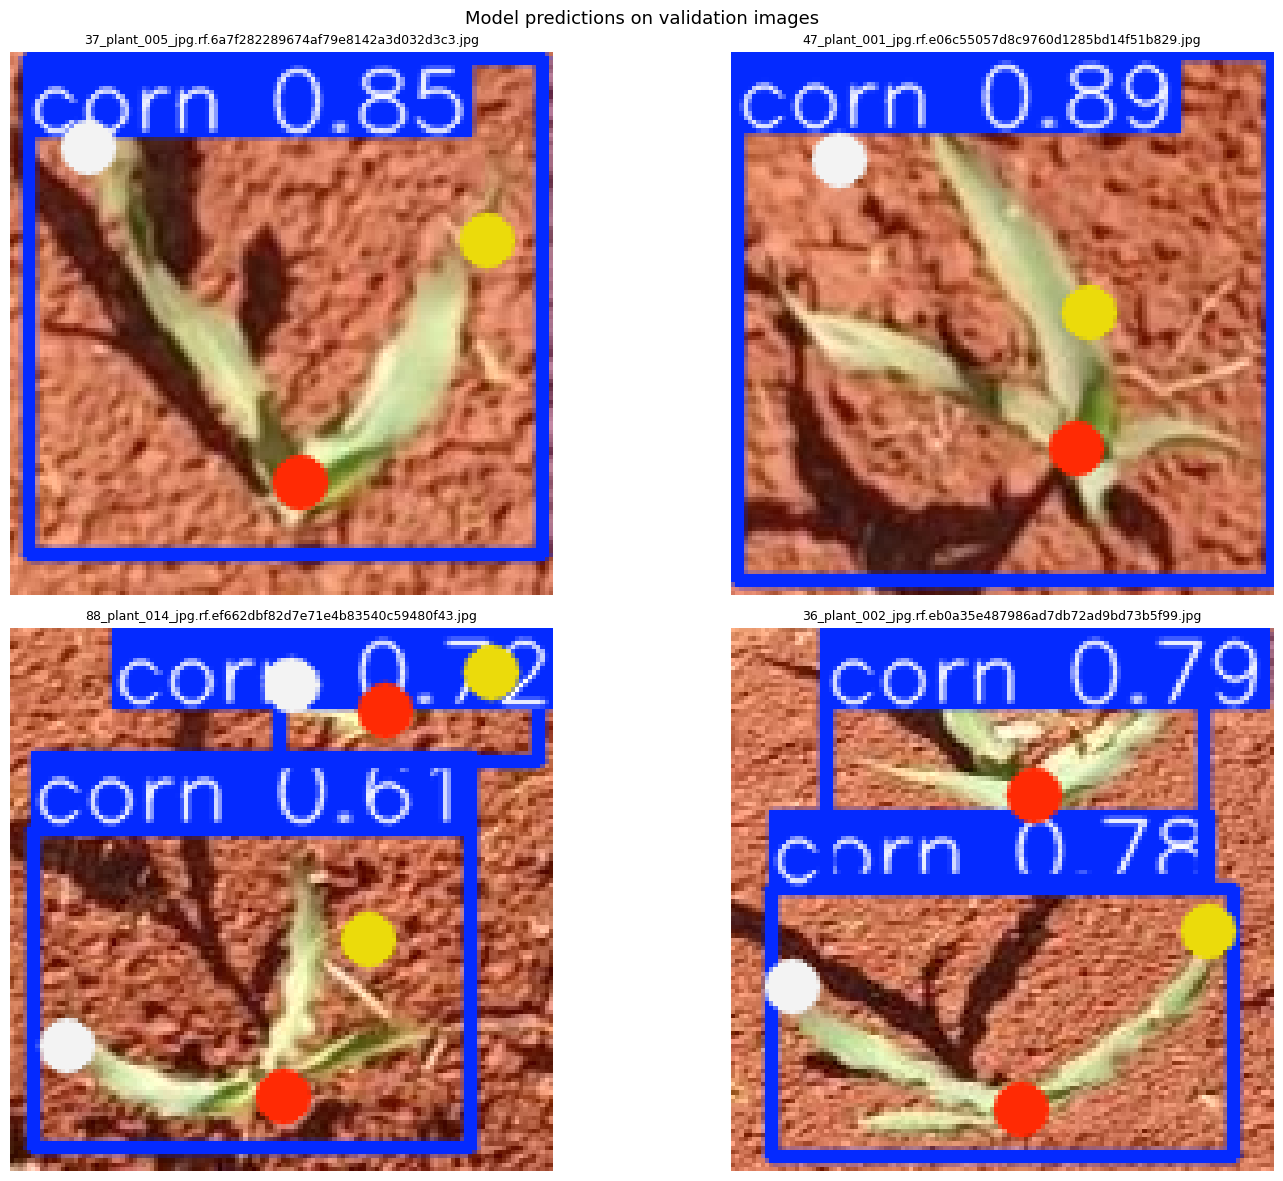

In [14]:
# --Sanity Check--
# Look at 4 random validation images with the model's predictions drawn on.

sample_val = random.sample(val_imgs, min(4, len(val_imgs)))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, img_path in zip(axes.ravel(), sample_val):
    # model.predict returns a Results object; [0] = results for image 0 (we pass one image)
    result = model.predict(str(img_path), conf=0.25, verbose=False)[0]
    # .plot() returns a numpy array with boxes + keypoints already drawn
    annotated = result.plot(kpt_radius=6, kpt_line=True)
    ax.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    ax.set_title(img_path.name, fontsize=9)
    ax.axis('off')
plt.suptitle("Model predictions on validation images", fontsize=13)
plt.tight_layout()
plt.show()

---
# 6. Inference Wrapper

The raw output of `model.predict()` is a complex object with tensors, confidence scores, etc. For the downstream code (row assignment, scoring), we want a simple list of dictionaries - one per plant - with named fields.

This cell defines a single function `detect_plants(image)` that returns a list like:

```python
[
    {
        'bbox':           [x1, y1, x2, y2],       # in pixels
        'confidence':     0.94,                    # how sure the model is (0 to 1)
        'stem':           (450.2, 312.1),          # (x, y) or None if not confident
        'left_tip':       (420.0, 295.3),
        'right_tip':      (485.7, 301.8),
        'leaf_axis_deg':  12.5,                    # angle of the left-right axis
    },
    ...
]
```

This is the clean interface every later cell uses.

In [15]:
# Confidence threshold for keypoints: below this, we treat the keypoint as "missing"
# rather than trusting a low-confidence guess. Tune based on section 5.2 results.
KP_CONF_THRESHOLD = 0.3


def axis_angle_deg(p_left, p_right):
    """
    Compute the angle of the axis through the two leaf tips.

    Returns angle in degrees in the range (-90, 90]:
      0 deg   = horizontal (tips are left-right)
      90 deg  = vertical   (one tip above the other)
      -45 deg = diagonal down-right

    Why (-90, 90] instead of (-180, 180]? Because an axis (a line) has no direction.
    An axis at +170 deg and an axis at -10 deg describe the same line.
    We normalize so downstream code doesn't have to worry about equivalent angles.
    """
    if p_left is None or p_right is None:
        return None  # can't compute an axis if either tip is missing

    dx = p_right[0] - p_left[0]
    dy = p_right[1] - p_left[1]
    # arctan2 gives signed angle in (-180, 180]; np.degrees converts radians to degrees
    angle = np.degrees(np.arctan2(dy, dx))

    # Wrap into (-90, 90] — flip by 180 deg if outside that range (same line, opposite direction)
    while angle >   90: angle -= 180
    while angle <= -90: angle += 180
    return angle


def detect_plants(image_or_path, conf=0.25, iou=0.5):
    """
    Run the trained model on one image and return a list of plant dictionaries.

    Parameters
    ----------
    image_or_path : str or np.ndarray
        Path to an image file, or an image array already loaded with cv2.
    conf : float
        Minimum confidence to keep a detection (0 to 1). 0.25 = keep everything that's
        25%+ likely to be a plant. Lower catches more, but with more false positives.
    iou : float
        IoU threshold for non-max suppression (merging overlapping detections).
    """
    # Run inference; [0] because predict returns a list (one per input image)
    r = model.predict(image_or_path, conf=conf, iou=iou, verbose=False)[0]
    if r.boxes is None or len(r.boxes) == 0:
        return []  # no plants detected

    # Pull tensors off the GPU and convert to numpy arrays for convenience
    boxes = r.boxes.xyxy.cpu().numpy()   # (N, 4) — each row is [x1, y1, x2, y2]
    confs = r.boxes.conf.cpu().numpy()   # (N,)   — confidence per detection
    kp_xy = r.keypoints.xy.cpu().numpy()  # (N, 3, 2) — (x, y) for each of 3 keypoints
    # Per-keypoint confidence isn't always exposed; fall back to 1.0 if unavailable
    try:
        kp_conf = r.keypoints.conf.cpu().numpy()  # (N, 3)
    except Exception:
        kp_conf = np.ones((len(boxes), NUM_KEYPOINTS))

    # Build our simple list of dictionaries
    plants = []
    for i in range(len(boxes)):

        def kp_or_none(idx):
            """Return keypoint (x,y) tuple or None if confidence is too low."""
            if kp_conf[i, idx] < KP_CONF_THRESHOLD:
                return None
            return (float(kp_xy[i, idx, 0]), float(kp_xy[i, idx, 1]))

        stem  = kp_or_none(KP_STEM)
        left  = kp_or_none(KP_LEFT)
        right = kp_or_none(KP_RIGHT)

        plants.append({
            'bbox':          boxes[i].tolist(),
            'confidence':    float(confs[i]),
            'stem':          stem,
            'left_tip':      left,
            'right_tip':     right,
            'leaf_axis_deg': axis_angle_deg(left, right),
        })
    return plants


# --- Quick demo ---
demo_path = random.choice(val_imgs)
plants = detect_plants(str(demo_path))
print(f"Detected {len(plants)} plants in {demo_path.name}")
# Print the first 3 plants to confirm the structure
for p in plants[:3]:
    print(f"  conf={p['confidence']:.2f}  stem={p['stem']}  axis={p['leaf_axis_deg']}")

Detected 1 plants in 85_plant_006_jpg.rf.d1433b36ec4d1b0919a22583d26c7182.jpg
  conf=0.85  stem=(70.56104278564453, 96.47982025146484)  axis=-9.46606243712884


---
# 7. Row Identity Helper

Our data is captured by taking pictures of small fragments of each seeded row, with the photographer knowing which plants belong to each row. Row identity is *declared*, not inferred. We expect field photos organized like:
```
field_photos/
├── row_0/
│   ├── plant_a.jpg
│   ├── plant_b.jpg
│   └── ...        (all photos of row 0)
├── row_1/
│   └── ...        (all photos of row 1)
├── row_2/
│   └── ...
...
```

Every image inside `row_N/` is treated as belonging to row N. This way the operator declares row identity at capture time — by walking down a row and putting all the photos in that row's folder — and the algorithm never has to guess.

## What this section provides

A small helper that walks a folder hierarchy and yields `(row_id, image_path)` pairs, preparing the pipeline for §8 (optimal line fitting) and §9 (scoring).

In [16]:
def walk_field_photos(field_root):
    """
    Walk a field-photos folder organized as `row_N/*.jpg` and yield (row_id, path)
    pairs.

    Parameters
    ----------
    field_root : Path
        Folder containing one subfolder per row, named `row_0`, `row_1`, etc.

    Yields
    ------
    (int, Path) tuples — the row id and the image path.
    """
    field_root = Path(field_root)
    if not field_root.exists():
        raise FileNotFoundError(f"Field photos folder not found: {field_root}")

    # Sort by row index so output is deterministic
    row_dirs = sorted(
        (d for d in field_root.iterdir() if d.is_dir() and d.name.startswith('row_')),
        key=lambda d: int(d.name.split('_')[1])
    )

    if not row_dirs:
        raise ValueError(
            f"No 'row_N/' subfolders found in {field_root}. "
            "Organize photos as field_photos/row_0/..., field_photos/row_1/..., etc."
        )

    for row_dir in row_dirs:
        row_id = int(row_dir.name.split('_')[1])
        # Common image extensions
        for ext in ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG'):
            for img_path in sorted(row_dir.glob(ext)):
                yield row_id, img_path


# --- Quick sanity-check ---
# Set this to your field-photos folder. The folder doesn't have to exist yet
# for the notebook to define the function — but you'll need it before running §10.
FIELD_PHOTOS_ROOT = PROJECT_ROOT / 'field_photos'

if FIELD_PHOTOS_ROOT.exists():
    print(f"Found field photos at: {FIELD_PHOTOS_ROOT}")
    counts = {}
    for row_id, _ in walk_field_photos(FIELD_PHOTOS_ROOT):
        counts[row_id] = counts.get(row_id, 0) + 1
    for rid in sorted(counts):
        print(f"  Row {rid}: {counts[rid]} photos")
else:
    print(f"No field photos folder yet at {FIELD_PHOTOS_ROOT}.")
    print("Once you have field photos, organize them as row_0/, row_1/, etc. there.")

Found field photos at: C:\Users\atpou\projects\T1_Corn_Alignment\field_photos
  Row 0: 20 photos
  Row 1: 20 photos
  Row 2: 20 photos
  Row 3: 20 photos


---
# 8. Optimal Line Calculation

In our greenhouse trial, the seeds were deliberately hand-planted along straight perpendicular lines. So the **optimal line is the row they were supposed to land on**

## Two ways to supply the optimal line

1. **If you know exactly where the rows were planted** (e.g., from the physical layout or a marking line in the image): use `OptimalLine.from_point_angle()` and hard-code the values. This is the most accurate.

2. **If you don't**: fit a line through the detected stems in each row using **RANSAC**. RANSAC stands for Random Sample Consensus. Unlike ordinary least-squares fitting, it ignores outliers (the few plants that were planted badly off-line). Those outliers are what we want to *score*, not fit our reference to.

In [18]:
from dataclasses import dataclass
from sklearn.linear_model import RANSACRegressor

def angular_diff_deg(a, b):
    """
    Smallest unsigned difference between two axis angles, normalized to [0, 90].

    Because an axis has no direction (line, not arrow), 170 deg and -10 deg describe
    the same axis, and their difference should be 0.
    """
    if a is None or b is None:
        return None
    d = abs(a - b) % 180
    return min(d, 180 - d)

@dataclass
class OptimalLine:
    """
    Represents a line in image coordinates as a point + unit direction vector.

    Why store it this way instead of slope + intercept? Because slope-intercept
    breaks down for vertical lines (infinite slope). Point + direction works for
    any line orientation.

    Attributes
    ----------
    px, py : float
        A point on the line, in image pixels.
    dx, dy : float
        The direction vector of the line (unit length: dx*dx + dy*dy = 1).
    """
    px: float
    py: float
    dx: float
    dy: float

    @classmethod
    def from_point_angle(cls, px, py, angle_deg):
        """Construct a line from a point and an angle in degrees."""
        t = np.radians(angle_deg)
        return cls(px, py, np.cos(t), np.sin(t))

    @classmethod
    def from_ransac(cls, stems_xy, residual_threshold=15.0, random_state=SEED):
        """
        Fit a line to a cloud of stem (x, y) points using RANSAC.

        residual_threshold (in pixels) = how far from the line a point can be
        while still counting as an inlier. Set this to your planting tolerance.
        """
        stems = np.asarray(stems_xy)
        if len(stems) < 2:
            # Degenerate — only one point; return a horizontal line through it
            return cls(stems[0, 0], stems[0, 1], 1.0, 0.0)

        X, y = stems[:, 0:1], stems[:, 1]

        # Detect near-vertical rows and handle them separately.
        # A near-vertical row has very little x-spread — fitting y(x) is unstable.
        # We fit x(y) instead and then flip the result back.
        if X.std() < y.std() * 0.2:
            # Near-vertical case: regress x on y
            ry = RANSACRegressor(residual_threshold=residual_threshold,
                                 random_state=random_state).fit(stems[:, 1:2], stems[:, 0])
            m = ry.estimator_.coef_[0]     # slope of x = m*y + c
            c = ry.estimator_.intercept_   # intercept
            n = np.hypot(m, 1)              # magnitude for normalization
            # Direction vector (m, 1) normalized; passes through (c, 0)
            return cls(c, 0.0, m / n, 1.0 / n)
        else:
            # Normal case: regress y on x
            rx = RANSACRegressor(residual_threshold=residual_threshold,
                                 random_state=random_state).fit(X, y)
            m = rx.estimator_.coef_[0]      # slope of y = m*x + c
            c = rx.estimator_.intercept_
            n = np.hypot(1, m)
            # Direction vector (1, m) normalized; passes through (0, c)
            return cls(0.0, c, 1.0 / n, m / n)

    def perpendicular_distance(self, pt):
        """
        Signed perpendicular distance from a point to the line, in pixels.

        Uses the 2D cross-product formula:
          distance = (pt - P) x direction
        where x is the scalar cross product (positive = left of line, negative = right).

        We usually take the absolute value for scoring.
        """
        vx, vy = pt[0] - self.px, pt[1] - self.py
        return vx * self.dy - vy * self.dx

    def angle_deg(self):
        """Return the angle of the line in degrees, normalized to (-90, 90]."""
        a = np.degrees(np.arctan2(self.dy, self.dx))
        while a >   90: a -= 180
        while a <= -90: a += 180
        return a

---
# 9. Alignment Scores and Deviations Computation

## Per-plant deviations

For every plant, we compute two numbers:

- **Positional deviation** — perpendicular pixel distance from the stem to its row's optimal line. Directly measures "how far off is this plant from where it was supposed to be?"
- **Angular deviation** — absolute angle between the plant's leaf axis and the expected orientation. For our perpendicular trial, leaves should grow **across** the row, so the expected leaf axis is 90° off from the row direction. `EXPECTED_LEAF_OFFSET_DEG = 90°`.

## Per-plant score (0 to 100, higher = better)

We turn each deviation into a score in [0, 100]:

```
pos_score(d) = 100 * exp(-d / POS_TOLERANCE_PX)         # exponential decay
ang_score(delta) = 100 * max(0, 1 - delta / ANG_TOLERANCE_DEG)  # linear decay, clamped at 0
plant_score = 0.5 * pos_score + 0.5 * ang_score         # equal weighting
```

Why exponential decay for position? A plant 30 pixels off is bad, but a plant 60 pixels off isn't "twice as bad" — it's "qualitatively wrong." Exponential decay matches that intuition.

Why linear for angle? Because angle has a natural maximum (90° = completely perpendicular = 0 score makes sense); pegging the score at 0 past the tolerance is the simplest defensible rule.

## Per-row score

Average the plant scores within each row. Also report the fraction of plants within tolerance — this is the number a farmer would actually care about: "85% of my plants in row 3 are within spec."

## Tuning knobs

The two constants below control how "strict" the scoring is. **Set these based on what a farmer considers acceptable planting error**, not what the model can achieve. The brief calls this out as an open question — we can only answer it once we see real planting data.

In [20]:
# --- Scoring thresholds — tune these based on real-world planting tolerance ---
POS_TOLERANCE_PX  = 30.0      # pixel offset at which positional score drops to ~37/100 (1/e)
ANG_TOLERANCE_DEG = 20.0      # angle offset at which angular score hits 0/100
EXPECTED_LEAF_OFFSET_DEG = 90.0  # leaves grow across (perpendicular to) the row

def score_plants(plants, optimal_lines,
                 pos_tol=POS_TOLERANCE_PX,
                 ang_tol=ANG_TOLERANCE_DEG,
                 expected_offset=EXPECTED_LEAF_OFFSET_DEG):
    """
    Add scoring fields to each plant dict:
      pos_dev_px, ang_dev_deg, pos_score, ang_score, plant_score
    """
    for p in plants:
        rid = p['row_id']
        # Can't score plants with no row assignment or no stem
        if rid < 0 or rid not in optimal_lines or p['stem'] is None:
            p.update(dict(pos_dev_px=None, ang_dev_deg=None,
                          pos_score=None, ang_score=None, plant_score=None))
            continue

        line = optimal_lines[rid]

        # --- Positional deviation ---
        pos_dev = abs(line.perpendicular_distance(p['stem']))  # perpendicular distance, pixels
        p['pos_dev_px'] = pos_dev
        # Exponential decay: 100 at d=0, ~37 at d=pos_tol, ~14 at d=2*pos_tol
        p['pos_score']  = 100.0 * np.exp(-pos_dev / pos_tol)

        # --- Angular deviation ---
        if p['leaf_axis_deg'] is not None:
            # Expected leaf axis = row direction + 90 deg (perpendicular)
            expected_axis_deg = line.angle_deg() + expected_offset
            # Normalize expected axis to (-90, 90]
            while expected_axis_deg >   90: expected_axis_deg -= 180
            while expected_axis_deg <= -90: expected_axis_deg += 180

            ang_dev = angular_diff_deg(p['leaf_axis_deg'], expected_axis_deg)
            p['ang_dev_deg'] = ang_dev
            # Linear decay: 100 at dev=0, 0 at dev=ang_tol, still 0 beyond
            p['ang_score']   = 100.0 * max(0.0, 1.0 - ang_dev / ang_tol)
        else:
            p['ang_dev_deg'] = None
            p['ang_score']   = None

        # --- Combined score ---
        if p['ang_score'] is not None:
            p['plant_score'] = 0.5 * p['pos_score'] + 0.5 * p['ang_score']
        else:
            # If we couldn't compute angular (e.g., one leaf tip missing),
            # fall back to positional only
            p['plant_score'] = p['pos_score']
    return plants


def row_scores(plants):
    """
    Roll plant-level scores up to per-row summaries.

    For each row, returns:
      n              — number of plants
      mean_score     — average plant_score across the row
      mean_pos_px    — average positional deviation
      max_pos_px     — worst positional deviation (useful for spotting bad plants)
      mean_ang_deg   — average angular deviation
      within_tol_pct — fraction of plants within POS_TOLERANCE_PX
    """
    # Group plants by row
    rows = defaultdict(list)
    for p in plants:
        if p['row_id'] >= 0 and p['plant_score'] is not None:
            rows[p['row_id']].append(p)

    summary = {}
    for rid, plist in rows.items():
        pos_devs = [p['pos_dev_px']  for p in plist if p['pos_dev_px']  is not None]
        ang_devs = [p['ang_dev_deg'] for p in plist if p['ang_dev_deg'] is not None]
        scores   = [p['plant_score'] for p in plist]
        within   = sum(1 for d in pos_devs if d <= POS_TOLERANCE_PX) / max(1, len(pos_devs))

        summary[rid] = dict(
            n=len(plist),
            mean_score=float(np.mean(scores)),
            mean_pos_px=float(np.mean(pos_devs)) if pos_devs else None,
            max_pos_px=float(np.max(pos_devs)) if pos_devs else None,
            mean_ang_deg=float(np.mean(ang_devs)) if ang_devs else None,
            within_tol_pct=100.0 * within,
        )
    return summary

---
# 10. Running the Pipeline

This section runs the entire pipeline end-to-end on every photo in `field_photos/`. For each row:

1. Detect plants in every photo of that row (using §6's `detect_plants()`)
2. Collect every plant's stem position into one list per row
3. Fit one optimal line per row using RANSAC over all stems in that row (§8's `OptimalLine.from_ransac()`)
4. Score every plant in that row against that row's line (§9's `score_plants()`)

Two CSVs are written:

- **plants.csv** — one row per detected plant: image, row, position, deviations, score
- **rows.csv** — one row per row: n plants, mean score, mean/max positional deviation, mean angular deviation, % within tolerance

A visualization is produced for one example photo per row, color-coded by alignment score.

## Why fit the line on *all* stems in the row, not per-photo

A single field photo typically contains 1–3 plants — not enough to constrain a line on its own. By pooling all stems from all photos in a given row, RANSAC has dozens of points to work with, and outlier plants (badly-placed seeds) can't drag the line toward themselves. The resulting line represents the row's actual planted geometry, not whichever subset happened to be in any one photo.

In [22]:
def visualize_alignment(img_bgr, plants, optimal_lines):
    """
    Draw bounding boxes, keypoints, and optimal lines on the image.
    Color-code by plant score: green = good, yellow = medium, red = poor.
    """
    H, W = img_bgr.shape[:2]
    out = img_bgr.copy()

    # --- Draw optimal lines first (so plants are drawn on top) ---
    for rid, line in optimal_lines.items():
        # Extend the line across the image by walking a large distance in both directions
        t_vals = np.linspace(-max(W, H), max(W, H), 2)
        xs = line.px + t_vals * line.dx
        ys = line.py + t_vals * line.dy
        cv2.line(out, (int(xs[0]), int(ys[0])), (int(xs[1]), int(ys[1])),
                 (255, 255, 255), 2, cv2.LINE_AA)

    # --- Draw each plant with a score-dependent color ---
    for p in plants:
        if p['stem'] is None:
            continue

        score = p['plant_score'] if p['plant_score'] is not None else 0
        # Map score [0, 100] to a red-green gradient
        # (Note: OpenCV uses BGR order, not RGB)
        g = int(np.clip(score * 2.55,         0, 255))
        r = int(np.clip((100 - score) * 2.55, 0, 255))
        color = (0, g, r)  # BGR: blue=0, green=g, red=r

        # Bounding box
        x1, y1, x2, y2 = map(int, p['bbox'])
        cv2.rectangle(out, (x1, y1), (x2, y2), color, 2)

        # Stem
        sx, sy = map(int, p['stem'])
        cv2.circle(out, (sx, sy), 5, color, -1)

        # Leaf axis — line segment through the two tips
        if p['left_tip'] and p['right_tip']:
            lx, ly = map(int, p['left_tip'])
            rx, ry = map(int, p['right_tip'])
            cv2.line(out, (lx, ly), (rx, ry), color, 2)
            cv2.circle(out, (lx, ly), 4, (0, 200, 255), -1)  # cyan for left tip
            cv2.circle(out, (rx, ry), 4, (255, 200, 0), -1)  # orange for right tip

        # Score text above the bounding box
        if p['plant_score'] is not None:
            cv2.putText(out, f"{p['plant_score']:.0f}", (x1, y1 - 6),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    return out

Pass 1: detecting plants in all field photos...
  38_plant_003_jpg.rf.985ac8e8004305682c72ef440afa9b5c.jpg: row 0, 1 plants
  40_plant_008_jpg.rf.4fb3f2244cfd1dd6fc36b430c415e34d.jpg: row 0, 1 plants
  44_plant_009_jpg.rf.d39111c8fb448b1fb97eb05c4ea20e18.jpg: row 0, 1 plants
  61_plant_003_jpg.rf.854f8d5cb31b9cd5783c900aaf87f70c.jpg: row 0, 1 plants
  63_plant_005_jpg.rf.d58b600b8979dda38310f70d39ec29fe.jpg: row 0, 2 plants
  77_plant_006_jpg.rf.39fbd06bdd0d15e0fd1228bb272ea631.jpg: row 0, 1 plants
  79_plant_009_jpg.rf.8f377fcc27495f45143210bcf3287088.jpg: row 0, 2 plants
  81_plant_005_jpg.rf.d6f18b9b4f1d8d51f3556beca4306a01.jpg: row 0, 2 plants
  82_plant_012_jpg.rf.9e22c82490717a13f414721604c19182.jpg: row 0, 1 plants
  98_plant_014_jpg.rf.00ecedededd0fdb33c3f3c72176540a0.jpg: row 0, 1 plants
  38_plant_003_jpg.rf.985ac8e8004305682c72ef440afa9b5c.jpg: row 0, 1 plants
  40_plant_008_jpg.rf.4fb3f2244cfd1dd6fc36b430c415e34d.jpg: row 0, 1 plants
  44_plant_009_jpg.rf.d39111c8fb448b1fb9

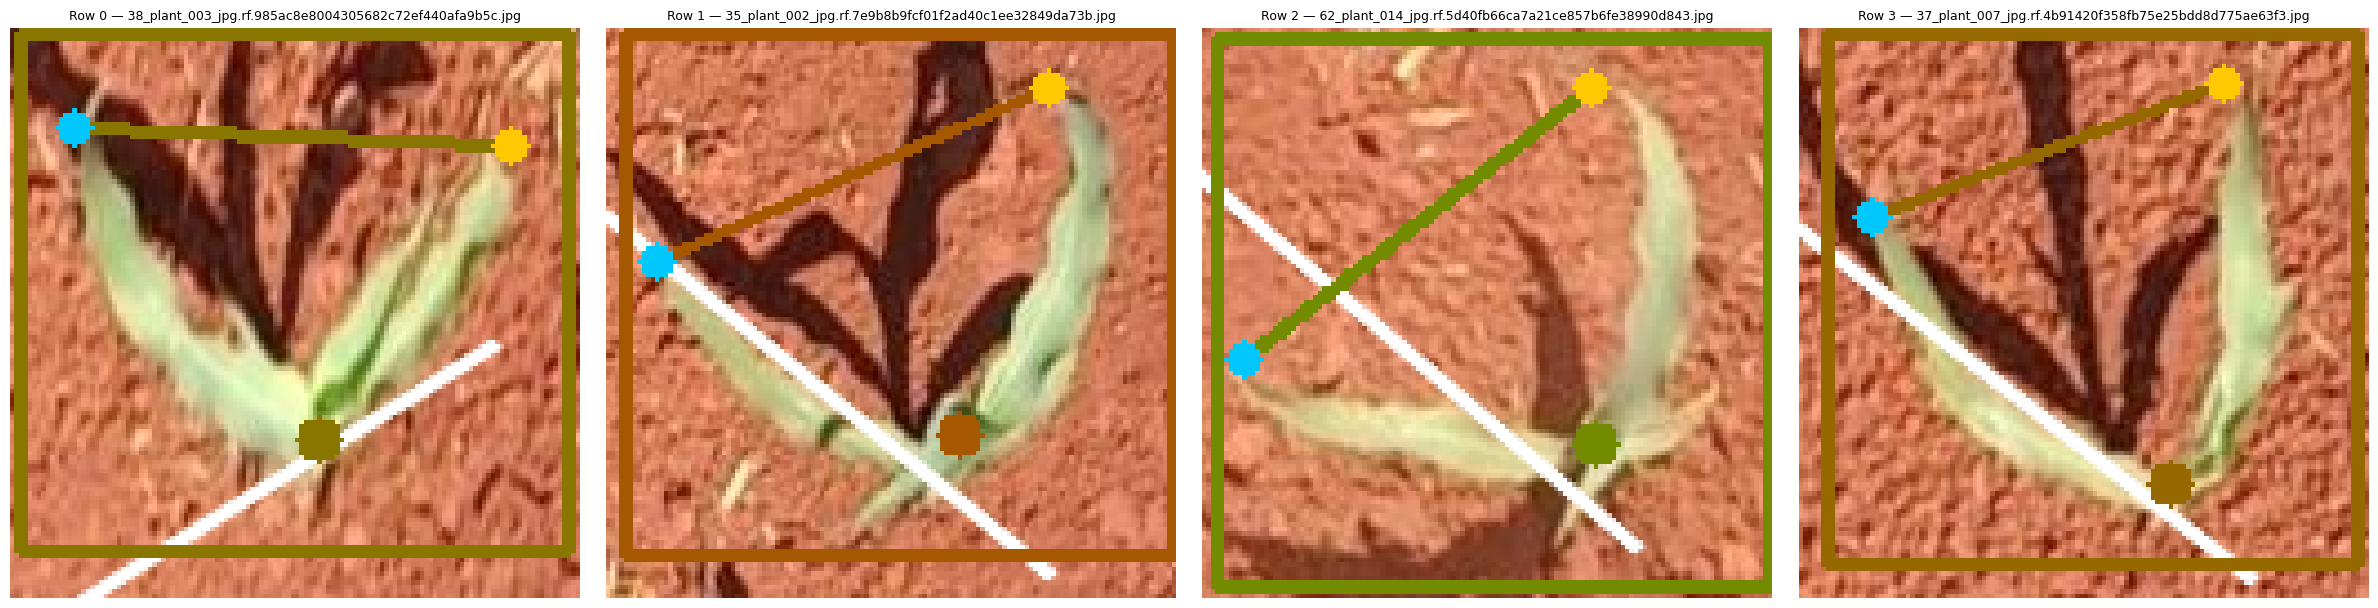

In [23]:
import csv  # standard library CSV writer

OUT_DIR = PROJECT_ROOT / 'results'
OUT_DIR.mkdir(exist_ok=True)
plant_csv = OUT_DIR / 'plants.csv'
row_csv   = OUT_DIR / 'rows.csv'

plant_header = ['image', 'row_id', 'x1', 'y1', 'x2', 'y2', 'conf',
                'stem_x', 'stem_y', 'left_x', 'left_y', 'right_x', 'right_y',
                'leaf_axis_deg', 'pos_dev_px', 'ang_dev_deg',
                'pos_score', 'ang_score', 'plant_score']
row_header = ['row_id', 'n_plants', 'mean_score',
              'mean_pos_px', 'max_pos_px', 'mean_ang_deg', 'within_tol_pct',
              'line_angle_deg']

# Confirm field photos exist before we start
if not FIELD_PHOTOS_ROOT.exists():
    raise FileNotFoundError(
        f"Field photos not found at {FIELD_PHOTOS_ROOT}. "
        "Create the folder and organize photos as row_0/, row_1/, etc. first."
    )

# --- Pass 1: detect every plant in every image, grouped by row ---
print("Pass 1: detecting plants in all field photos...")
row_observations = defaultdict(list)   # row_id → list of (image_path, plant)
for row_id, img_path in walk_field_photos(FIELD_PHOTOS_ROOT):
    plants = detect_plants(str(img_path))
    for p in plants:
        p['row_id'] = row_id
        row_observations[row_id].append((img_path, p))
    if plants:
        print(f"  {img_path.name}: row {row_id}, {len(plants)} plants")

# --- Pass 2: fit one optimal line per row using all collected stems ---
print("\nPass 2: fitting optimal line per row...")
optimal_lines = {}
for row_id in sorted(row_observations):
    stems = [p['stem'] for _, p in row_observations[row_id] if p.get('stem')]
    if len(stems) < 2:
        print(f"  Row {row_id}: only {len(stems)} stems — skipping line fit")
        continue
    try:
        line = OptimalLine.from_ransac(stems, residual_threshold=20.0)
        optimal_lines[row_id] = line
        print(f"  Row {row_id}: line fit on {len(stems)} stems, "
              f"angle={line.angle_deg():+.1f}°")
    except Exception as e:
        print(f"  Row {row_id}: line fit failed — {e}")

# --- Pass 3: score every plant against its row's line and write CSVs ---
print("\nPass 3: scoring and writing CSVs...")
with open(plant_csv, 'w', newline='') as fp, open(row_csv, 'w', newline='') as fr:
    pw = csv.writer(fp); pw.writerow(plant_header)
    rw = csv.writer(fr); rw.writerow(row_header)

    for row_id, observations in sorted(row_observations.items()):
        if row_id not in optimal_lines:
            continue
        plants = [p for _, p in observations]
        plants = score_plants(plants, {row_id: optimal_lines[row_id]})

        # Per-plant rows
        for (img_path, _), p in zip(observations, plants):
            pw.writerow([
                img_path.name, p['row_id'],
                *[f"{v:.1f}" for v in p['bbox']], f"{p['confidence']:.3f}",
                *(f"{v:.1f}" for v in (p['stem']      or (np.nan, np.nan))),
                *(f"{v:.1f}" for v in (p['left_tip']  or (np.nan, np.nan))),
                *(f"{v:.1f}" for v in (p['right_tip'] or (np.nan, np.nan))),
                f"{p['leaf_axis_deg']:.1f}" if p.get('leaf_axis_deg') is not None else '',
                f"{p['pos_dev_px']:.1f}"   if p.get('pos_dev_px')   is not None else '',
                f"{p['ang_dev_deg']:.1f}"  if p.get('ang_dev_deg')  is not None else '',
                f"{p['pos_score']:.1f}"    if p.get('pos_score')    is not None else '',
                f"{p['ang_score']:.1f}"    if p.get('ang_score')    is not None else '',
                f"{p['plant_score']:.1f}"  if p.get('plant_score')  is not None else '',
            ])

        # Per-row summary
        summary = row_scores(plants).get(row_id, {})
        if summary:
            rw.writerow([
                row_id, summary['n'], f"{summary['mean_score']:.2f}",
                f"{summary['mean_pos_px']:.2f}" if summary['mean_pos_px'] is not None else '',
                f"{summary['max_pos_px']:.2f}"  if summary['max_pos_px']  is not None else '',
                f"{summary['mean_ang_deg']:.2f}" if summary['mean_ang_deg'] is not None else '',
                f"{summary['within_tol_pct']:.2f}",
                f"{optimal_lines[row_id].angle_deg():+.2f}",
            ])

print(f"\nWrote {plant_csv}")
print(f"Wrote {row_csv}")

# --- Visualize one example photo per row ---
print("\nGenerating visualization for one image per row...")
n_rows_to_show = min(len(row_observations), 4)
fig, axes = plt.subplots(1, n_rows_to_show, figsize=(6 * n_rows_to_show, 6))
if n_rows_to_show == 1:
    axes = [axes]

for ax, row_id in zip(axes, sorted(row_observations)[:n_rows_to_show]):
    if row_id not in optimal_lines:
        ax.axis('off'); ax.set_title(f"Row {row_id} — no line fit")
        continue
    img_path, _ = row_observations[row_id][0]
    img = cv2.imread(str(img_path))
    plants_in_image = [p for ip, p in row_observations[row_id] if ip == img_path]
    plants_in_image = score_plants(plants_in_image, {row_id: optimal_lines[row_id]})
    vis = visualize_alignment(img, plants_in_image, {row_id: optimal_lines[row_id]})
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(f"Row {row_id} — {img_path.name}", fontsize=9)
    ax.axis('off')

plt.tight_layout(); plt.show()

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# Per-row results summary — read the CSVs and display them cleanly
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd

rows_df   = pd.read_csv(OUT_DIR / 'rows.csv')
plants_df = pd.read_csv(OUT_DIR / 'plants.csv')

# ── Per-row summary table ─────────────────────────────────────────────────────
print("=" * 78)
print("PER-ROW SUMMARY")
print("=" * 78)
print(f"{'Row':>4}  {'n':>4}  {'mean':>6}  {'mean pos':>9}  {'max pos':>9}  "
      f"{'mean ang':>9}  {'within tol':>11}  {'line angle':>11}")
print("-" * 78)
for _, r in rows_df.sort_values('row_id').iterrows():
    print(
        f"{int(r['row_id']):>4}  "
        f"{int(r['n_plants']):>4}  "
        f"{r['mean_score']:>6.1f}  "
        f"{r['mean_pos_px']:>8.1f}px  "
        f"{r['max_pos_px']:>8.1f}px  "
        f"{r['mean_ang_deg']:>8.1f}°  "
        f"{r['within_tol_pct']:>10.1f}%  "
        f"{r['line_angle_deg']:>+10.1f}°"
    )
print("-" * 78)

# ── Overall stats ────────────────────────────────────────────────────────────
print()
print("=" * 78)
print("OVERALL")
print("=" * 78)
total_plants = int(rows_df['n_plants'].sum())
weighted_mean = (
    (rows_df['mean_score'] * rows_df['n_plants']).sum() / total_plants
    if total_plants else float('nan')
)
print(f"Total plants scored:     {total_plants}")
print(f"Rows analyzed:           {len(rows_df)}")
print(f"Weighted mean score:     {weighted_mean:.1f}")
print(f"Best row:                {int(rows_df.loc[rows_df['mean_score'].idxmax(), 'row_id'])} "
      f"(score {rows_df['mean_score'].max():.1f})")
print(f"Worst row:               {int(rows_df.loc[rows_df['mean_score'].idxmin(), 'row_id'])} "
      f"(score {rows_df['mean_score'].min():.1f})")

# ── Worst-aligned plants — useful for spot-checking failure cases ───────────
print()
print("=" * 78)
print("10 WORST-ALIGNED PLANTS (lowest plant_score)")
print("=" * 78)
worst = (plants_df
         .dropna(subset=['plant_score'])
         .sort_values('plant_score')
         .head(10))
print(f"{'row':>4}  {'image':<55}  {'score':>6}  {'pos px':>7}  {'ang°':>5}")
print("-" * 78)
for _, p in worst.iterrows():
    img = str(p['image'])
    if len(img) > 55:
        img = img[:52] + '...'
    print(
        f"{int(p['row_id']):>4}  {img:<55}  "
        f"{p['plant_score']:>6.1f}  "
        f"{p['pos_dev_px']:>6.1f}  "
        f"{p['ang_dev_deg']:>5.1f}"
    )

PER-ROW SUMMARY
 Row     n    mean   mean pos    max pos   mean ang   within tol   line angle
------------------------------------------------------------------------------
   0    26    30.6      22.3px      66.3px      69.0°        69.2%       -31.8°
   1    20    45.4       6.1px      11.0px      33.6°       100.0%       +39.0°
   2    20    50.6       5.6px      19.6px      42.3°       100.0%       +40.4°
   3    24    37.1      11.1px      52.0px      49.3°        91.7%       +37.9°
------------------------------------------------------------------------------

OVERALL
Total plants scored:     90
Rows analyzed:           4
Weighted mean score:     40.0
Best row:                2 (score 50.6)
Worst row:               0 (score 30.6)

10 WORST-ALIGNED PLANTS (lowest plant_score)
 row  image                                                     score   pos px   ang°
------------------------------------------------------------------------------
   0  40_plant_008_jpg.rf.4fb3f2244cfd1dd6f

---
# 11. Closing notes — how each deliverable is addressed, and what to tune

## The five deliverables, mapped to code

| Deliverable | Where |
|-------------|-------|
| 1. Corn detection model | §4 trains `yolo11-pose`; §5 validates it |
| 2. Position + orientation per plant | §6 returns stem + leaf axis per plant |
| 3. Optimal growth line per row | §10 fits one line per row using §8's `OptimalLine.from_ransac()`, pooling all stems from all photos in `row_N/` |
| 4. Deviation from optimal | §9 computes positional (pixels) + angular (degrees) deviation |
| 5. Plant and row alignment scores | §10 batch CSV export |

## The four "important aspects" from the brief

- **How is the optimal line defined?** It's fit by RANSAC over all detected stems in a given row. RANSAC ignores outliers, so badly-placed plants don't drag the reference line toward themselves and instead get the bad scores they deserve.
- **Planting-accuracy consistency?** Read the per-plant deviations in `plants.csv` — the distribution gives you the answer empirically.
- **Detection accuracy needed for "helpful" outcomes?** §5.2 reports per-keypoint pixel error. Stem median 4.35 px is well within `POS_TOLERANCE_PX / 3 = 10` px, so scoring noise is small vs. real planting noise.
- **Weather robustness?** §4.1's augmentation simulates varied lighting, occlusion, and perspective. Real field images are the real test.

## Knobs to re-tune as the project evolves

| Knob | Cell | What it controls |
|------|------|------------------|
| `POS_TOLERANCE_PX`  | §9 | Pixel offset at which positional score drops to 37% |
| `ANG_TOLERANCE_DEG` | §9 | Angle at which angular score hits 0 |
| `EXPECTED_LEAF_OFFSET_DEG` | §9 | 90° for perpendicular trial, 0° for along-row trial |
| `residual_threshold` in `from_ransac` | §10 | Planting-accuracy tolerance for line fitting |

## What's deliberately left out

- **Pixel-to-centimeter conversion.** Requires camera calibration. Add a single `PX_PER_CM` constant once measured.
- **Real-time / robot integration.** Lives in the separate live notebook (`VeXtronicsCodeLive.ipynb`).

## Companion notebook

For the live camera demo (Bluetooth or USB webcam, real-time scoring as the camera moves over the field), see `VeXtronicsCodeLive.ipynb`. That notebook shares §1–§6 and §8–§9 with this one but replaces §7 onwards with a video-stream pipeline.